# Titanic Survival Prediction Model

Comprehensive ML pipeline to predict Titanic passenger survival using EDA, feature engineering, and multiple classification models.

## Section 0 — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, f1_score
from sklearn.impute import KNNImputer
import xgboost as xgb
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns:\n{train.dtypes}")
print(f"\nTrain head:\n{train.head()}")

Train shape: (891, 12)
Test shape: (418, 11)

Train columns:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Train head:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen,

In [3]:
# Extract target and prepare for unified feature engineering
target = train['Survived']
train_len = len(train)

# Combine train and test for unified feature engineering (prevents train/test skew)
all_data = pd.concat([train.drop('Survived', axis=1), test], ignore_index=True)
print(f"Combined data shape: {all_data.shape}")
print(f"\nMissing values:\n{all_data.isnull().sum()}")

Combined data shape: (1309, 11)

Missing values:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


## Section 1 — EDA

In [4]:
# Survival rate
survival_rate = target.mean()
print(f"Survival rate: {survival_rate:.2%}")
print(f"Positive class: {target.sum()}/{len(target)}")
print(f"Negative class: {(1-target).sum()}/{len(target)}")

Survival rate: 38.38%
Positive class: 342/891
Negative class: 549/891


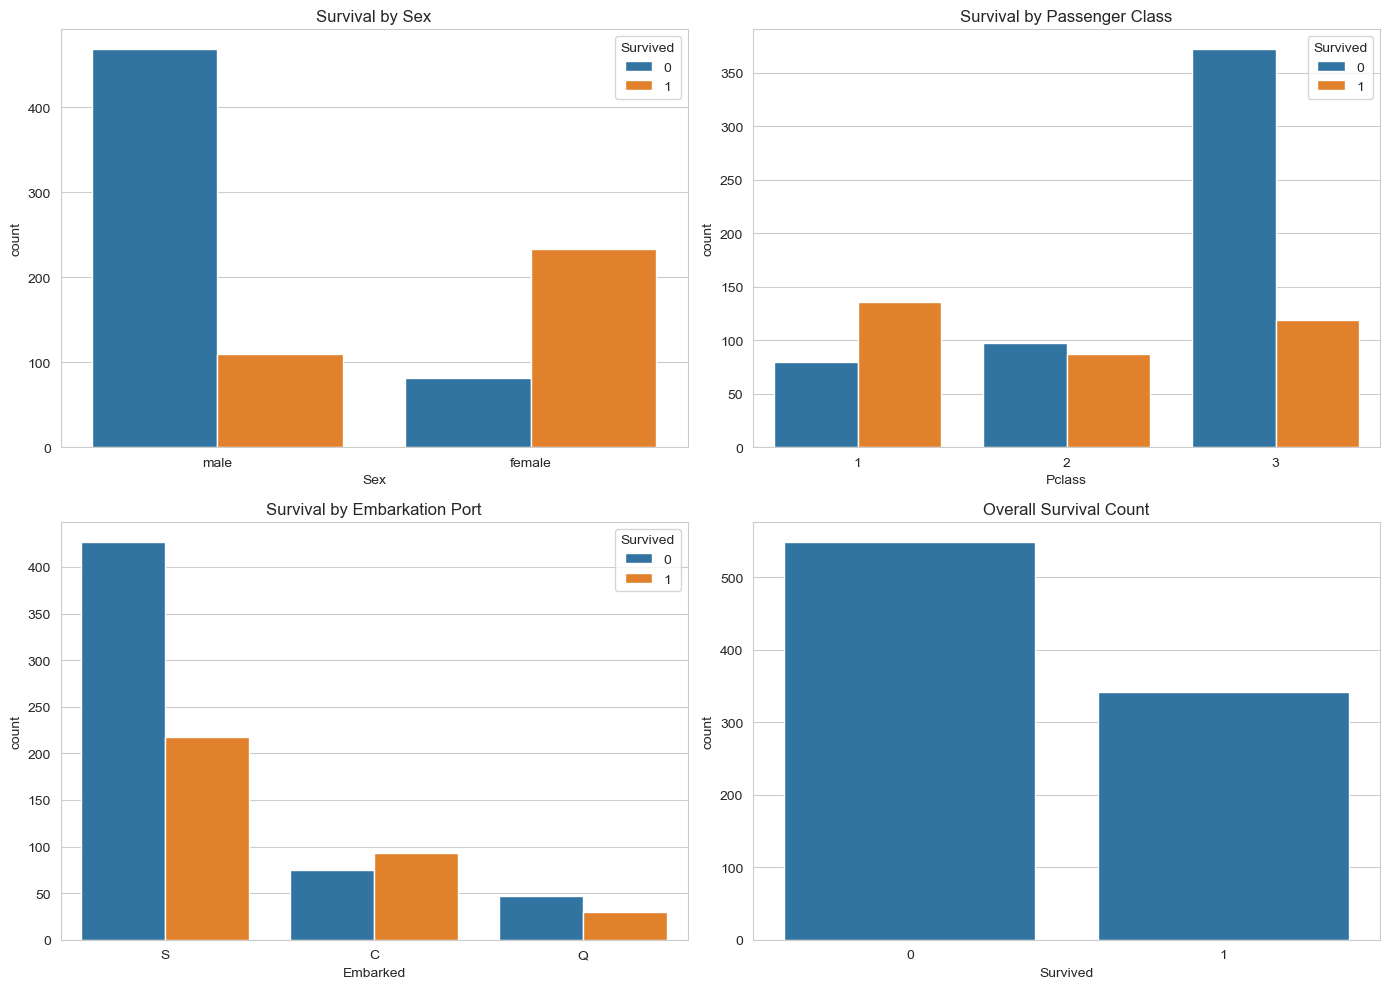

In [5]:
# Countplots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sex
sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')

# Pclass
sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Passenger Class')

# Embarked
sns.countplot(data=train, x='Embarked', hue='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival by Embarkation Port')

# Overall Survived
sns.countplot(data=train, x='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Overall Survival Count')

plt.tight_layout()
plt.show()

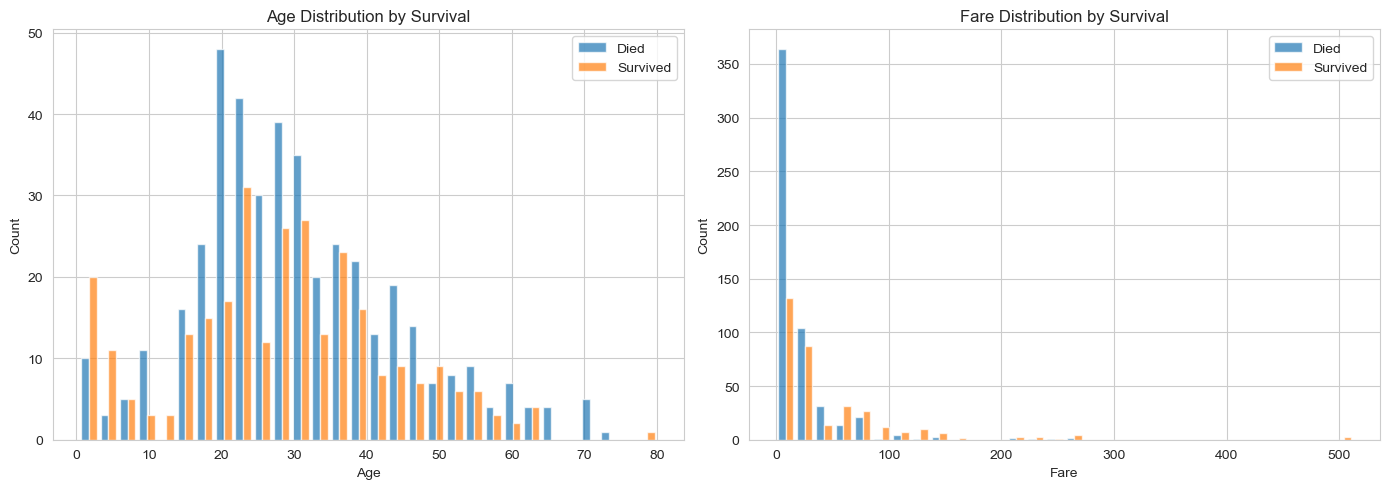

In [6]:
# Histplots for numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
axes[0].hist([train[train['Survived']==0]['Age'].dropna(),
              train[train['Survived']==1]['Age'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Survival')
axes[0].legend()

# Fare
axes[1].hist([train[train['Survived']==0]['Fare'].dropna(),
              train[train['Survived']==1]['Fare'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].set_title('Fare Distribution by Survival')
axes[1].legend()

plt.tight_layout()
plt.show()

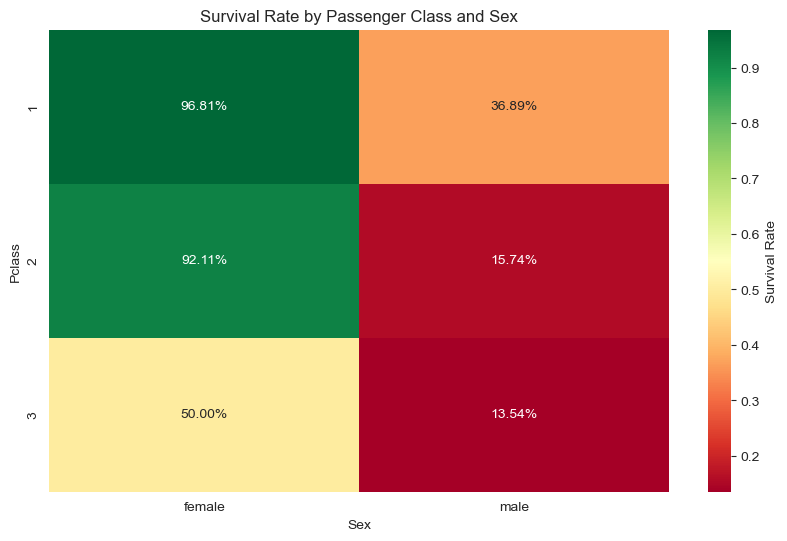

In [7]:
# Heatmap: survival rate by Pclass × Sex
survival_by_pclass_sex = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
sns.heatmap(survival_by_pclass_sex, annot=True, fmt='.2%', cmap='RdYlGn', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Passenger Class and Sex')
plt.show()

In [8]:
# Missing value summary on combined data
missing_summary = all_data.isnull().sum()
missing_pct = (missing_summary / len(all_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

          Missing Count  Percentage
Cabin              1014       77.46
Age                 263       20.09
Embarked              2        0.15
Fare                  1        0.08


## Section 2 — Feature Engineering (on all_data)

In [9]:
# Create a copy for feature engineering
df = all_data.copy()

# Extract Title from Name
def extract_title(name):
    title_match = re.search(r' ([A-Za-z]+)\.', name)
    return title_match.group(1) if title_match else 'Unknown'

df['Title'] = df['Name'].apply(extract_title)
print(f"Unique titles: {df['Title'].unique()}")
print(f"\nTitle counts:\n{df['Title'].value_counts()}")

Unique titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer' 'Dona']

Title counts:
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Mlle          2
Major         2
Ms            2
Lady          1
Sir           1
Mme           1
Don           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


In [10]:
# Consolidate rare titles
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

print(f"Consolidated title counts:\n{df['Title'].value_counts()}")

Consolidated title counts:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [11]:
# KNN imputation for Age and other numeric features
# This preserves inter-feature correlations better than median imputation
knn_imp = KNNImputer(n_neighbors=5)
numeric_cols = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']
df[numeric_cols] = knn_imp.fit_transform(df[numeric_cols])

print(f"Missing Age after KNN imputation: {df['Age'].isnull().sum()}")
print(f"Missing Fare after KNN imputation: {df['Fare'].isnull().sum()}")

Missing Age after KNN imputation: 0
Missing Fare after KNN imputation: 0


In [12]:
# Extract Deck from Cabin
df['Deck'] = df['Cabin'].fillna('U').apply(lambda x: x[0])
print(f"Unique decks: {sorted(df['Deck'].unique())}")
print(f"\nDeck counts:\n{df['Deck'].value_counts()}")

Unique decks: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'U']

Deck counts:
Deck
U    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


In [13]:
# Fill missing Fare with median
df['Fare'].fillna(df['Fare'].median(), inplace=True)
print(f"Missing Fare after imputation: {df['Fare'].isnull().sum()}")

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(f"Missing Embarked after imputation: {df['Embarked'].isnull().sum()}")

Missing Fare after imputation: 0
Missing Embarked after imputation: 0


In [14]:
# Engineer new features

# FamilySize: total family on ship
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: binary flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# FamilySize binning: different survival patterns by group size
df['FamilySizeGroup'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 11],
                                labels=['Alone', 'Small', 'Large'])

# LogFare: log transform (handles Fare=0)
df['LogFare'] = np.log1p(df['Fare'])

# FarePerPerson: wealth proxy (fare adjusted for family size)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df['LogFarePerPerson'] = np.log1p(df['FarePerPerson'])

# FareBin: quantile-based binning
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Very Low', 'Low', 'Mid', 'High'], duplicates='drop')

# AgeBin: age groups
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# Pclass × Sex Interaction: captures non-linear survival patterns
df['Pclass_1_Female'] = ((df['Pclass'] == 1) & (df['Sex'] == 'female')).astype(int)
df['Pclass_2_Female'] = ((df['Pclass'] == 2) & (df['Sex'] == 'female')).astype(int)
df['Pclass_3_Male'] = ((df['Pclass'] == 3) & (df['Sex'] == 'male')).astype(int)

# Age × Title interaction: captures age patterns within passenger classes
title_age_mean = df.groupby('Title')['Age'].transform('mean')
df['AgeTitle_Interaction'] = df['Age'] * title_age_mean / 100  # normalized

# LogFare × Pclass interaction: captures wealth patterns by class
df['LogFarePclass_Interaction'] = df['LogFare'] * df['Pclass']

print(f"New features created:")
print(f"FamilySize: {df['FamilySize'].describe()}")
print(f"FamilySizeGroup: {df['FamilySizeGroup'].value_counts()}")
print(f"IsAlone: {df['IsAlone'].value_counts()}")
print(f"\nFarePerPerson: {df['FarePerPerson'].describe()}")
print(f"\nFareBin: {df['FareBin'].value_counts(dropna=False)}")
print(f"\nAgeBin: {df['AgeBin'].value_counts(dropna=False)}")
print(f"\nInteraction features:")
print(f"Pclass_1_Female: {df['Pclass_1_Female'].sum()}")
print(f"Pclass_2_Female: {df['Pclass_2_Female'].sum()}")
print(f"Pclass_3_Male: {df['Pclass_3_Male'].sum()}")
print(f"AgeTitle_Interaction: {df['AgeTitle_Interaction'].describe()}")
print(f"LogFarePclass_Interaction: {df['LogFarePclass_Interaction'].describe()}")

New features created:
FamilySize: count    1309.000000
mean        1.883881
std         1.583639
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: FamilySize, dtype: float64
FamilySizeGroup: FamilySizeGroup
Alone    790
Small    437
Large     82
Name: count, dtype: int64
IsAlone: IsAlone
1    790
0    519
Name: count, dtype: int64

FarePerPerson: count    1309.000000
mean       20.509648
std        35.762002
min         0.000000
25%         7.452767
50%         8.566667
75%        24.150000
max       512.329200
Name: FarePerPerson, dtype: float64

FareBin: FareBin
Very Low    337
Mid         328
High        323
Low         321
Name: count, dtype: int64

AgeBin: AgeBin
YoungAdult    719
Adult         354
Teen          109
Child          94
Senior         33
Name: count, dtype: int64

Interaction features:
Pclass_1_Female: 144
Pclass_2_Female: 106
Pclass_3_Male: 493
AgeTitle_Interaction: count    1309.000000
mean        9.56173

## Section 3 — Preprocessing

In [15]:
# Select final features
# Removed: Fare (redundant with LogFare), FarePerPerson (redundant with LogFarePerPerson), IsAlone (subsumed by FamilySizeGroup)
# Added: AgeTitle_Interaction, LogFarePclass_Interaction
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'LogFare',
                'LogFarePerPerson', 'FamilySize', 'FamilySizeGroup',
                'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked',
                'Pclass_1_Female', 'Pclass_2_Female', 'Pclass_3_Male',
                'AgeTitle_Interaction', 'LogFarePclass_Interaction']

# Drop unnecessary columns
df = df[feature_cols].copy()
print(f"Final features shape: {df.shape}")
print(f"Feature count: {len(feature_cols)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Final features shape: (1309, 19)
Feature count: 19

Data types:
Pclass                        float64
Sex                            object
Age                           float64
SibSp                         float64
Parch                         float64
LogFare                       float64
LogFarePerPerson              float64
FamilySize                    float64
FamilySizeGroup              category
Title                          object
Deck                           object
FareBin                      category
AgeBin                       category
Embarked                       object
Pclass_1_Female                 int64
Pclass_2_Female                 int64
Pclass_3_Male                   int64
AgeTitle_Interaction          float64
LogFarePclass_Interaction     float64
dtype: object

Missing values:
Pclass                       0
Sex                          0
Age                          0
SibSp                        0
Parch                        0
LogFare                     

In [16]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Sex', 'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked', 'FamilySizeGroup'],
                            drop_first=False)

# Convert all columns to numeric (handles category dtypes from pd.cut/pd.qcut)
df_encoded = df_encoded.astype('float64')

print(f"Encoded features shape: {df_encoded.shape}")
print(f"\nFirst few rows:\n{df_encoded.head()}")

Encoded features shape: (1309, 43)

First few rows:
   Pclass   Age  SibSp  Parch   LogFare  LogFarePerPerson  FamilySize  \
0     3.0  22.0    1.0    0.0  2.110213          1.531476         2.0   
1     1.0  38.0    1.0    0.0  4.280593          3.601186         2.0   
2     3.0  26.0    0.0    0.0  2.188856          2.188856         1.0   
3     1.0  35.0    1.0    0.0  3.990834          3.316003         2.0   
4     3.0  35.0    0.0    0.0  2.202765          2.202765         1.0   

   Pclass_1_Female  Pclass_2_Female  Pclass_3_Male  ...  AgeBin_Teen  \
0              0.0              0.0            1.0  ...          0.0   
1              1.0              0.0            0.0  ...          0.0   
2              0.0              0.0            0.0  ...          0.0   
3              1.0              0.0            0.0  ...          0.0   
4              0.0              0.0            1.0  ...          0.0   

   AgeBin_YoungAdult  AgeBin_Adult  AgeBin_Senior  Embarked_C  Embarked_Q  \

In [17]:
# Re-split into train and test
X_train = df_encoded[:train_len].copy()
X_test = df_encoded[train_len:].copy()
y_train = target.copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (891, 43)
X_test shape: (418, 43)
y_train shape: (891,)


In [18]:
# Align X_test columns to X_train (handles unseen categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"After alignment:")
print(f"X_train columns: {X_train.shape[1]}")
print(f"X_test columns: {X_test.shape[1]}")
print(f"Column mismatch: {set(X_train.columns) - set(X_test.columns)}")

After alignment:
X_train columns: 43
X_test columns: 43
Column mismatch: set()


## Section 4 — Model Training & Comparison

In [19]:
# Initialize models with optimized parameters
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5,
                                           min_samples_leaf=4, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.07,
                                                   max_depth=4, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.03,
                                max_depth=4, random_state=42, use_label_encoder=False,
                                eval_metric='logloss',
                                scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate using ROC-AUC scoring
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name:25} | Mean: {scores.mean():.4f} ± {scores.std():.4f} | Scores: {scores}")

Logistic Regression       | Mean: 0.8781 ± 0.0173 | Scores: [0.91152833 0.87005348 0.86156417 0.87473262 0.87242388]


Random Forest             | Mean: 0.8751 ± 0.0194 | Scores: [0.90309618 0.86938503 0.85688503 0.8540107  0.89196915]


Gradient Boosting         | Mean: 0.8820 ± 0.0279 | Scores: [0.9326087  0.87874332 0.85347594 0.86002674 0.88518814]


XGBoost                   | Mean: 0.8826 ± 0.0176 | Scores: [0.90592885 0.87553476 0.85641711 0.87680481 0.89808536]


In [20]:
# Grid Search for hyperparameter tuning on Random Forest (best individual model)
print("Running GridSearchCV for Random Forest optimization...")

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'min_samples_leaf': [3, 4, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_grid, cv=skf, scoring='roc_auc', n_jobs=-1, verbose=0
)

rf_grid.fit(X_train, y_train)
print(f"\nBest RF params: {rf_grid.best_params_}")
print(f"Best RF ROC-AUC: {rf_grid.best_score_:.4f}")
print(f"Best estimator depth: {rf_grid.best_estimator_.max_depth}")

Running GridSearchCV for Random Forest optimization...



Best RF params: {'max_depth': 6, 'min_samples_leaf': 4, 'n_estimators': 300}
Best RF ROC-AUC: 0.8783
Best estimator depth: 6


In [21]:
# Stacking Ensemble using best-tuned base learners
print("Building Stacking Ensemble...")

# Use best RF params from GridSearchCV
estimators = [
    ('rf', RandomForestClassifier(**rf_grid.best_params_, class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.07, max_depth=4, random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.03, max_depth=4,
                               scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
                               eval_metric='logloss', random_state=42, use_label_encoder=False))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False
)

# Evaluate stacking model
stack_scores = cross_val_score(stacking_model, X_train, y_train, cv=skf, scoring='roc_auc')
print(f"Stacking CV ROC-AUC: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}")

# Compare all models and select best
all_models = {
    'RF (Grid Search)': rf_grid.best_score_,
    'Gradient Boosting': cv_results['Gradient Boosting'].mean(),
    'XGBoost': cv_results['XGBoost'].mean(),
    'Stacking Ensemble': stack_scores.mean()
}

print(f"\n=== Model Comparison (ROC-AUC) ===")
for model_name, score in sorted(all_models.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25} | {score:.4f}")

# Select best model
best_model_name = max(all_models, key=all_models.get)
if best_model_name == 'Stacking Ensemble':
    best_model = stacking_model
    print(f"\n✓ Best model: {best_model_name}")
else:
    best_model = rf_grid.best_estimator_
    print(f"\n✓ Best model: {best_model_name}")

Building Stacking Ensemble...


Stacking CV ROC-AUC: 0.8841 ± 0.0235

=== Model Comparison (ROC-AUC) ===
Stacking Ensemble         | 0.8841
XGBoost                   | 0.8826
Gradient Boosting         | 0.8820
RF (Grid Search)          | 0.8783

✓ Best model: Stacking Ensemble


In [22]:
# Store results for later use
best_model_name = max(cv_results, key=lambda x: cv_results[x].mean())
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name}")


Best model: XGBoost


## Section 5 — Evaluation

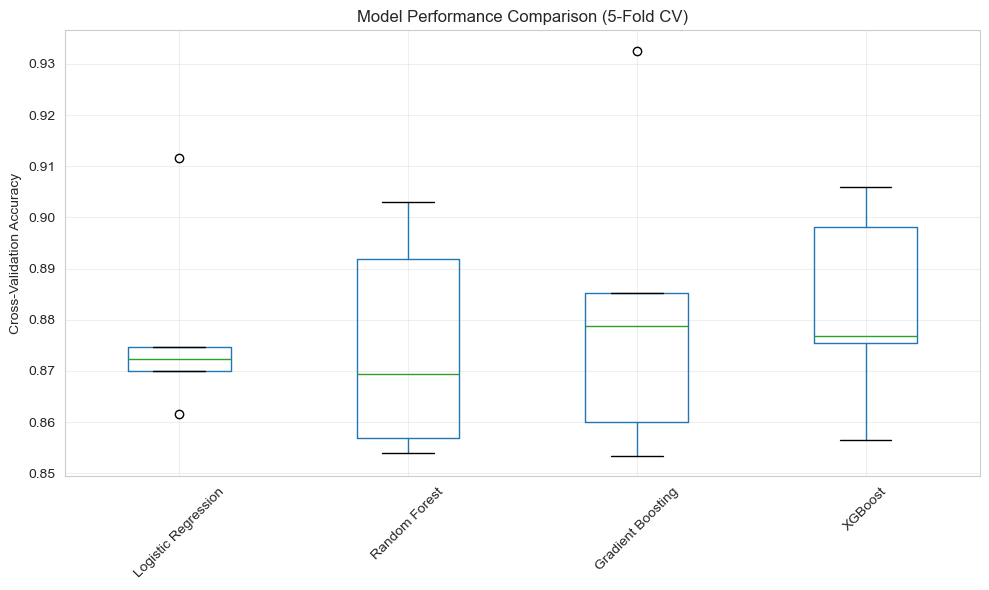

In [23]:
# Boxplot comparing CV accuracy across models
results_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
results_df.boxplot(ax=ax)
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Model Performance Comparison (5-Fold CV)')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Optimizing classification threshold for F1 score...



Threshold Optimization Results:
Optimal threshold: 0.52
F1 score at optimal threshold: 0.7841
Default threshold (0.5) F1: 0.7791


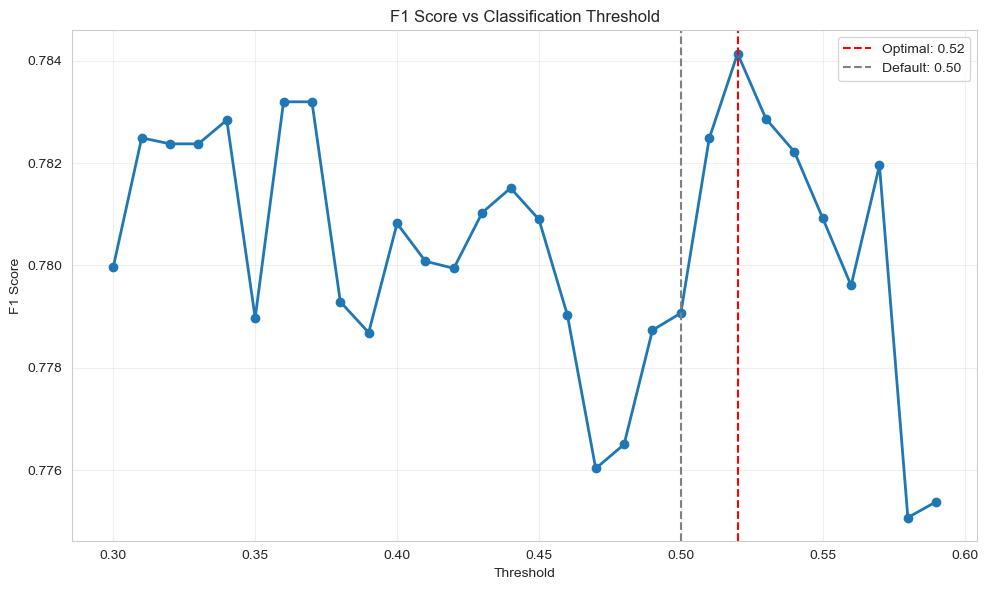

In [24]:
# Threshold optimization for imbalanced data (38% survival rate)
print("Optimizing classification threshold for F1 score...")

# Get out-of-fold probability predictions
y_proba_oof = cross_val_predict(best_model, X_train, y_train, cv=skf, method='predict_proba')[:, 1]

# Find optimal threshold
thresholds = np.arange(0.3, 0.6, 0.01)
f1_scores = [f1_score(y_train, (y_proba_oof >= t).astype(int)) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]

print(f"\nThreshold Optimization Results:")
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"F1 score at optimal threshold: {max(f1_scores):.4f}")
print(f"Default threshold (0.5) F1: {f1_score(y_train, (y_proba_oof >= 0.5).astype(int)):.4f}")

# Plot threshold vs F1
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, marker='o', linewidth=2)
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle='--', label='Default: 0.50')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Fit best model on full training data
best_model.fit(X_train, y_train)
y_pred_train = best_model.predict(X_train)

print(f"Best model: {best_model_name}")
print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

Best model: XGBoost
Training accuracy: 0.9024


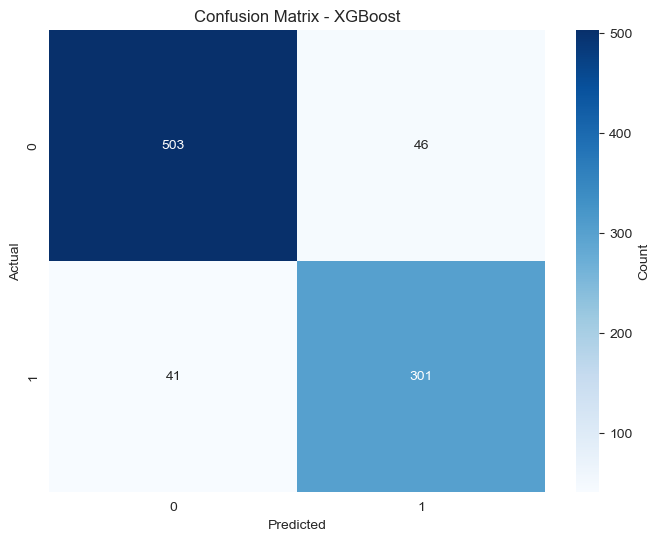

In [26]:
# Confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [27]:
# Make predictions on test set using optimal threshold
print(f"Making predictions with optimal threshold: {optimal_threshold:.2f}")

# Get probability predictions
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Apply optimal threshold
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

print(f"Predictions shape: {y_pred_test.shape}")
print(f"Unique predictions: {np.unique(y_pred_test)}")
print(f"Survival rate in predictions: {y_pred_test.mean():.2%}")

Making predictions with optimal threshold: 0.52
Predictions shape: (418,)
Unique predictions: [0 1]
Survival rate in predictions: 40.67%


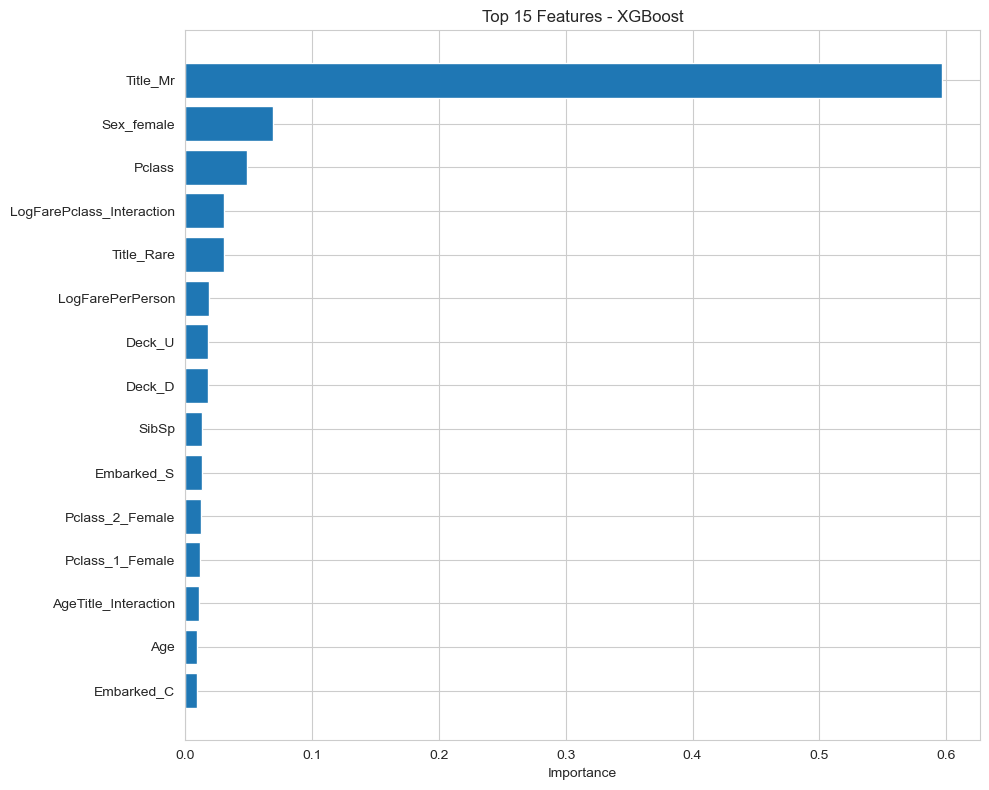


Top 15 Features:
                      Feature  Importance
16                   Title_Mr    0.596659
12                 Sex_female    0.069633
0                      Pclass    0.048612
11  LogFarePclass_Interaction    0.031185
18                 Title_Rare    0.031158
5            LogFarePerPerson    0.018944
27                     Deck_U    0.018140
22                     Deck_D    0.018099
2                       SibSp    0.013767
39                 Embarked_S    0.013608
8             Pclass_2_Female    0.012465
7             Pclass_1_Female    0.011797
10       AgeTitle_Interaction    0.010994
1                         Age    0.009922
37                 Embarked_C    0.009591


In [28]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    # Plot top 15 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    ax.barh(range(len(top_15)), top_15['Importance'])
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 Features - {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f"\nTop 15 Features:\n{top_15}")
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'coef_'):
    # For Logistic Regression via Pipeline
    coef = best_model.named_steps['model'].coef_[0]
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    }).sort_values('Coefficient', ascending=False, key=abs)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    colors = ['green' if x > 0 else 'red' for x in top_15['Coefficient']]
    ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Coefficient')
    ax.set_title(f'Top 15 Features - {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f"\nTop 15 Features:\n{top_15}")

## Section 6 — Final Prediction & Submission

In [29]:
# Make predictions on test set
y_pred_test = best_model.predict(X_test)

print(f"Predictions shape: {y_pred_test.shape}")
print(f"Unique predictions: {np.unique(y_pred_test)}")
print(f"Survival rate in predictions: {y_pred_test.mean():.2%}")

Predictions shape: (418,)
Unique predictions: [0 1]
Survival rate in predictions: 41.39%


In [30]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred_test.astype(int)
})

print(f"Submission shape: {submission.shape}")
print(f"\nFirst 10 rows:\n{submission.head(10)}")
print(f"\nLast 10 rows:\n{submission.tail(10)}")

Submission shape: (418, 2)

First 10 rows:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Last 10 rows:
     PassengerId  Survived
408         1300         1
409         1301         1
410         1302         1
411         1303         1
412         1304         1
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         1


In [31]:
# Save submission
submission.to_csv('../outputs/submission.csv', index=False)
print(f"Submission saved to ../outputs/submission.csv")

# Verify against schema
gender_submission = pd.read_csv('../data/gender_submission.csv')
print(f"\nGender submission shape: {gender_submission.shape}")
print(f"Our submission shape: {submission.shape}")
print(f"\nSchema match: {list(submission.columns) == list(gender_submission.columns)}")
print(f"All predictions are 0 or 1: {set(submission['Survived']).issubset({0, 1})}")

Submission saved to ../outputs/submission.csv

Gender submission shape: (418, 2)
Our submission shape: (418, 2)

Schema match: True
All predictions are 0 or 1: True
